## ADP

**ADP** (Aerosol Data Protocol) is a protocol developed by Aerosol d.o.o. for standardized data exchange between instruments and data acquisition systems. It allows for real-time data retrieval, control and monitoring of compatible instruments.

ADP works with **AE36s**, **AE36**, **TCA08** and **TCA09** instruments, while **AE33 is not supported** (AE33 uses legacy AE33 data protocol, which behaves similarly, only commands are different).

**License:** Aerosol Magee Scientific Software License (See LICENSE file for full terms).

In [67]:
from datetime import timedelta, datetime
from io import StringIO

import pandas as pd

from aerosol_magee_pytools.data_access.tcp_ip import request_tcp, guess_delimiter
from aerosol_magee_pytools.instruments.column_names import COLUMNS_AE36S, COLUMNS_TCA09, COLUMNS_TCA08
from aerosol_magee_pytools.tools import dotnet_seconds_to_datetime, datetime_to_dotnet_nanoseconds

In [68]:
# IP of the instrument - change it to the actual IP address of your AE36s instrument
# instrument_ip = '10.10.10.80' # Skylab AE36s
# instrument_ip = '10.10.10.133' # Skylab TCA08
instrument_ip = '10.10.10.61' # Skylab TCA09

timeout = 2.0  # seconds

In [69]:
### command INFO
command = '$AERO:INFO\r\n'
received_text = request_tcp(ip=instrument_ip,
                            command=command,
                            timeout=timeout)
print(received_text)

# parse info response to a dictionary
info = {}
for line in received_text.splitlines():
    line = line.strip()
    if not line or ':' not in line:
        continue
    key, value = line.split(':', 1)
    info[key.strip()] = value.strip()

# there are different fields in INFO response between TCA and AE36, let's synchronize info
if 'Serialnumber' in info:
    info['Serial Number'] = info.pop('Serialnumber' )
    info['Model number'] = info['Serial Number'].split('-')[0]

instrument_typ = info['Model number']
print()
print(f"Instrument type: {instrument_typ}")
print()
print(info)

Instrument name: Total Carbon Analyzer
Model number: TCA09
Serial Number: TCA09-P1-00004
Firmware version: 108
Software version: 0.226.0.0
Current date and time: 6/23/2026 12:41:41 PM

Instrument type: TCA09

{'Instrument name': 'Total Carbon Analyzer', 'Model number': 'TCA09', 'Serial Number': 'TCA09-P1-00004', 'Firmware version': '108', 'Software version': '0.226.0.0', 'Current date and time': '6/23/2026 12:41:41 PM'}


In [70]:
### command LAST return entry from chosen table (table DATA in our case)
command = '$AERO:LAST DATA\r\n'
received_text = request_tcp(ip=instrument_ip,
                            command=command,
                            timeout=timeout)
print(received_text)

12602,3963,639178038006057259,639178110006057259,639178056006891185,639178128006891185,639178056006057259,639178128006057259,639178067557106653,639178139557106653,338,106,"Sample 3963",4.91,0,1,1,2,1,0,0,0,1,1,0.4,306,21,2925,596,5964,644,2,16.68,0.2,490.41,101.32,25,501,20.4,398.8,102.2,335.55,129.61,205.94,5302.8,100,0.65,5638.35,325.65,259.22,66.43,408.06,51.47,98.33,417.18,0.09,24.1,14.64,0.07,0,8750,2599,62,60,396,46,34,11,1706,1,420.297856860167,-0.0236749274475927,0.000765144042740186,-7.83248461458987E-06,3.16101452914908E-08,-4.40311204452054E-11,415.375234328769,-0.0285053670547641,1.25137115088353E-05,-5.76072747392454E-07,5.25428620104261E-09,-1.0271937002333E-11


**FETCH** command allows you to retrieve data from the instrument for a specific time period.

**Note:** On AE36, AE36s and TCA09, the data is stored in the table named `Data`, while on TCA08, data is stored in the table named `OnlineResults` (table named `Data` on TCA08 is acctually debug_data).

In [71]:
### command FETCH return data from chosen table and time period of last 24 hours on TCA or last 6 hours on Aethalometer

#### limit time to resent data
end = datetime.now().isoformat(sep=' ', timespec='seconds')
start = (datetime.now() - timedelta(hours=6)).isoformat(sep=' ', timespec='seconds')
if 'TCA' in instrument_typ:
    start = (datetime.now() - timedelta(days=1)).isoformat(sep=' ', timespec='seconds')
###

if instrument_typ != 'TCA08':
    # command = '$AERO:FETCH DATA "2026-06-11 12:51:00" "2026-06-11 15:51:00"\r\n'
    command = f'$AERO:FETCH DATA "{start}" "{end}"\r\n'
else:
    # command = '$AERO:FETCH OnlineResults "2026-06-11 12:51:00" "2026-06-11 15:51:00
    command = f'$AERO:FETCH OnlineResult "{start}" "{end}"\r\n'

received_text = request_tcp(ip=instrument_ip,
                            command=command,
                            timeout=timeout)
print(received_text)

12556,3917,639177210003319850,639177282003319850,639177228003216346,639177300003216346,639177228003319850,639177300003319850,639177239553900521,639177311553900521,338,106,"Sample 3917",4.91,0,1,1,2,1,0,0,0,1,1,0.38,341,20,3260,664,6647,644,2,16.68,0.2,490.42,101.32,25,800,16.85,665.2,134.8,487.81,216.19,271.62,5639.19,100,0.65,6127,520,432.38,87.62,414.63,51.47,98.59,423.64,0.09,24.1,15.51,0.07,0,8348,2575,60,59,395,45,34,11,1680,1,425.241752204238,-0.00320828691186329,0.000479942000867275,-5.17274939975967E-06,2.05784160262776E-08,-2.80727623745304E-11,422.005438758876,-0.030401842818663,0.000125295573561372,-2.01480663878849E-06,1.2142130986741E-08,-2.12693796295086E-11
12557,3918,639177228003216346,639177300003216346,639177246004050275,639177318004050275,639177246003216346,639177318003216346,639177257554578225,639177329554578225,338,106,"Sample 3918",4.91,0,1,1,1,2,0,0,0,1,2,0.39,330,17,3336,679,6802,644,2,16.68,0.2,490.41,101.32,25,581,18.82,471.66,109.34,373.62,153.29,220.33,6050.

In [72]:
# in the end, you can parse data, for example, convert it into pandas dataframe;
# you will need column names first

if instrument_typ in ['AE36', 'AE36s']:
    columns = COLUMNS_AE36S['Data']
elif instrument_typ == 'TCA08':
    columns = COLUMNS_TCA08['OnlineResult']
elif instrument_typ == 'TCA09':
    columns = COLUMNS_TCA09['Data']
else:
    raise ValueError(f"Unsupported instrument type: {instrument_typ}")

# python can automatically determine the delimiter
separator = guess_delimiter(received_text)

df_data = pd.read_csv(StringIO(received_text.strip()),
                      sep=separator,
                      names=columns)

# convert instrument timestamps stored as nanoseconds from .NET epoch into pandas datetime
for column in df_data.columns:
    if ('Timestamp' in column) or column.endswith('TimeUTC') or column.endswith('TimeLocal'):
        if instrument_typ != 'TCA08':
            df_data[column] = dotnet_seconds_to_datetime(df_data[column])
        else:
            df_data[column] = pd.to_datetime(df_data[column])

print(df_data.shape)
print(df_data)

(47, 82)
       ID  SampleID  SampleStartTimeUTC SampleStartTimeLocal  \
0   12556      3917 2026-06-22 10:30:00  2026-06-22 12:30:00   
1   12557      3918 2026-06-22 11:00:00  2026-06-22 13:00:00   
2   12558      3919 2026-06-22 11:30:00  2026-06-22 13:30:00   
3   12559      3920 2026-06-22 12:00:00  2026-06-22 14:00:00   
4   12560      3921 2026-06-22 12:30:00  2026-06-22 14:30:00   
5   12561      3922 2026-06-22 13:00:00  2026-06-22 15:00:00   
6   12562      3923 2026-06-22 13:30:00  2026-06-22 15:30:00   
7   12563      3924 2026-06-22 14:00:00  2026-06-22 16:00:00   
8   12564      3925 2026-06-22 14:30:00  2026-06-22 16:30:00   
9   12565      3926 2026-06-22 15:00:00  2026-06-22 17:00:00   
10  12566      3927 2026-06-22 15:30:00  2026-06-22 17:30:00   
11  12567      3928 2026-06-22 16:00:00  2026-06-22 18:00:00   
12  12568      3929 2026-06-22 16:30:00  2026-06-22 18:30:00   
13  12569      3930 2026-06-22 17:00:00  2026-06-22 19:00:00   
14  12570      3931 2026-06-22 

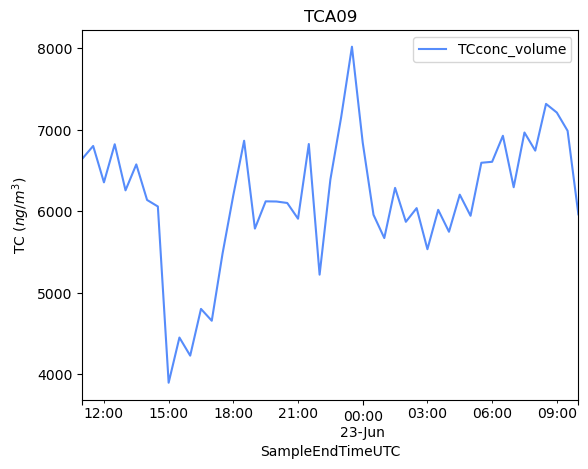

In [73]:
# plot data
if instrument_typ in ['AE36s', 'AE36']:
    df_data['TimestampUTC'] = pd.to_datetime(df_data['TimestampUTC'], errors='coerce')
    df_data.plot(x='TimestampUTC', y='BC880', title=f'{instrument_typ}', ylabel='BC ($ng/m^3$)')

elif instrument_typ == 'TCA08':
    df_data['EndTimeUTC'] = pd.to_datetime(df_data['EndTimeUTC'], errors='coerce')
    df_data.plot(x='EndTimeUTC', y='TCconc', title=f'{instrument_typ}', ylabel='TC ($ng/m^3$)')

elif instrument_typ == 'TCA09':
    df_data = df_data[df_data['SampleEndTimeUTC'] != 0]
    df_data['SampleEndTimeUTC'] = pd.to_datetime(df_data['SampleEndTimeUTC'], errors='coerce')
    df_data.plot(x='SampleEndTimeUTC', y='TCconc_volume', title=f'{instrument_typ}', ylabel='TC ($ng/m^3$)')